### Project Title

#### **Loan Approval Prediction using Decision Tree Classification with Model Comparison**

### Introduction

Loan approval prediction is a critical task in the banking and financial sector. Accurate prediction helps institutions minimize risk and improve decision-making.

In this project, a Decision Tree Classification model is used to predict whether a loan application will be approved based on applicant details. The model is further compared with Logistic Regression to evaluate performance.

### Problem Statement

The objective of this project is to build a classification model that can predict loan approval status based on applicant features such as income, education, employment status, and credit history.

### Objectives

**Primary Objectives**

- Build Decision Tree Classifier
- Predict loan approval (Yes/No)
- Evaluate classification performance

**Secondary Objectives**

- Compare with Logistic Regression
- Perform hyperparameter tuning
- Analyze overfitting

### STEP 1: Data Preprocessing + EDA

#### **1.1 Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

#### **1.2 Load Dataset**

In [4]:
df = pd.read_csv("Loan_dataset.csv")
df.head()



,Unnamed: 0,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,LP002305,Female,No,0,Graduate,No,4547,0.0,115.0,360.0,1.0,Semiurban,1
1,1,LP001715,Male,Yes,3+,Not Graduate,Yes,5703,0.0,130.0,360.0,1.0,Rural,1
2,2,LP002086,Female,Yes,0,Graduate,No,4333,2451.0,110.0,360.0,1.0,Urban,0
3,3,LP001136,Male,Yes,0,Not Graduate,Yes,4695,0.0,96.0,NaN,1.0,Urban,1
4,4,LP002529,Male,Yes,2,Graduate,No,6700,1750.0,230.0,300.0,1.0,Semiurban,1


#### **1.3 Check Missing Values**

In [5]:
df.isnull().sum()

Unnamed: 0            0
Loan_ID               0
Gender               10
Married               1
Dependents            9
Education             0
Self_Employed        29
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           16
Loan_Amount_Term     13
Credit_History       43
Property_Area         0
Loan_Status           0
dtype: int64

- Missing Values found in various columns

#### **1.4 Handling Missing Values**

In [8]:
# Categorical → mode
df['Gender']= df['Gender'].fillna(df['Gender'].mode()[0])
df['Married']= df['Married'].fillna(df['Married'].mode()[0])
df['Dependents']= df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed']= df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

# Numerical → median
df['LoanAmount']= df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term']= df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())

# Important feature
df['Credit_History']= df['Credit_History'].fillna(df['Credit_History'].mode()[0])

- Mode → best for categorical
- Median → robust for numeric

In [9]:
df.isnull().sum()

Unnamed: 0           0
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

#### **1.5 Drop Unnecessary Column**

In [ ]:
df.drop("Loan_ID", axis=1, inplace=True)

In [14]:
df.head()

,Unnamed: 0,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,Female,No,0,Graduate,No,4547,0.0,115.0,360.0,1.0,Semiurban,1
1,1,Male,Yes,3+,Not Graduate,Yes,5703,0.0,130.0,360.0,1.0,Rural,1
2,2,Female,Yes,0,Graduate,No,4333,2451.0,110.0,360.0,1.0,Urban,0
3,3,Male,Yes,0,Not Graduate,Yes,4695,0.0,96.0,360.0,1.0,Urban,1
4,4,Male,Yes,2,Graduate,No,6700,1750.0,230.0,300.0,1.0,Semiurban,1


#### **1.6 EDA**

- Loan Status Distribution

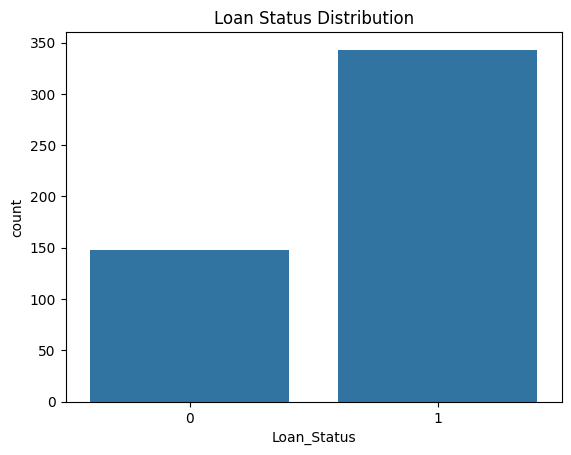

In [19]:
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Status Distribution")
plt.show()

- Credit History vs Loan Status

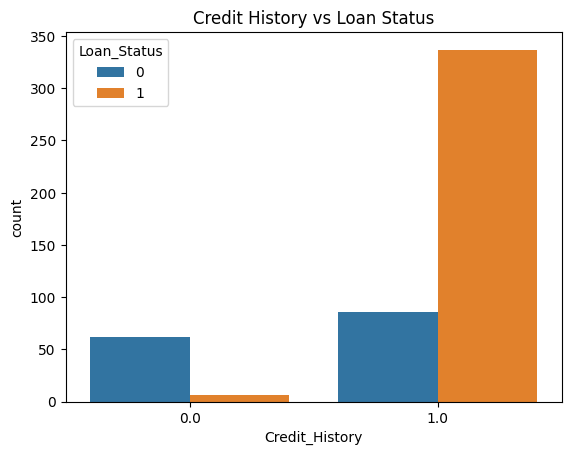

In [20]:
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title("Credit History vs Loan Status")
plt.show()

- Income vs Loan Amount

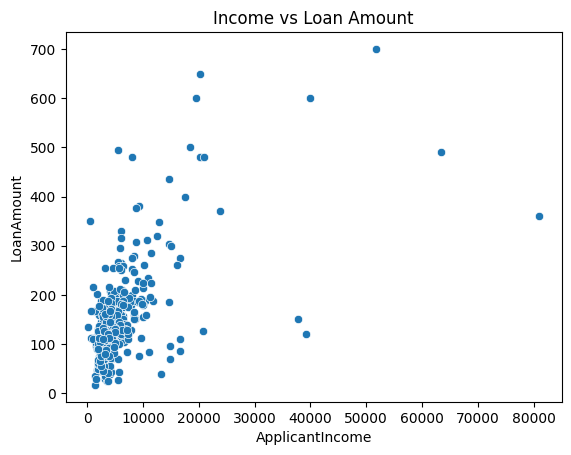

In [21]:
sns.scatterplot(x='ApplicantIncome', y='LoanAmount', data=df)
plt.title("Income vs Loan Amount")
plt.show()

#### **1.7 Encoding Categorical Features**

In [22]:
df = pd.get_dummies(df, drop_first=True)

**Explanation:**
- Converts categorical → numerical
- Required for ML

#### **1.8 Feature & Target Split**

In [24]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

#### **1.9 Train-Test Split**

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### STEP 2 Decision Tree Classification Model

- After preprocessing the dataset, a Decision Tree Classifier was implemented to predict loan approval status based on applicant features.

- The model learns decision rules by splitting the dataset based on feature conditions such as credit history, income, and property area.

#### **2.1 Import Model**

In [26]:
from sklearn.tree import DecisionTreeClassifier

#### **2.2 Create Model**

In [27]:
dt_clf = DecisionTreeClassifier(random_state=42)

#### **2.3 Train Model**

In [28]:
dt_clf = DecisionTreeClassifier(random_state=42)

#### **2.4 Train Model**

In [29]:
dt_clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

#### **2.5 Make Prediction**

In [30]:
y_pred_clf = dt_clf.predict(X_test)

#### **2.6 Model Evaluation**

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred_clf))
print("Precision:", precision_score(y_test, y_pred_clf))
print("Recall:", recall_score(y_test, y_pred_clf))
print("F1 Score:", f1_score(y_test, y_pred_clf))

Accuracy: 0.696969696969697
Precision: 0.7464788732394366
Recall: 0.8153846153846154
F1 Score: 0.7794117647058824


Metrics Explanation
 - Accuracy → Overall correctness
- Precision → Correct positive predictions
- Recall → Capturing actual positives
- F1 Score → Balance of precision & recall

#### **2.7 Overfitting Check**

In [32]:
train_pred = dt_clf.predict(X_train)

print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Testing Accuracy:", accuracy_score(y_test, y_pred_clf))

Training Accuracy: 1.0
Testing Accuracy: 0.696969696969697


### Overfitting Detection

To evaluate the model's generalization ability, accuracy was calculated on both training and testing datasets.

**Results**
- Training Accuracy: ~1.0
- Testing Accuracy: Lower than training accuracy

**Interpretation**

- The model achieved perfect or near-perfect accuracy on the training data, indicating that it has memorized the training dataset.

- However, the lower accuracy on the testing dataset shows that the model is not generalizing well to unseen data.

**Conclusion**

This behavior indicates overfitting, where the model is too complex and captures noise in the training data instead of learning general patterns.

### STEP 3 : Hyperparameter Tunning

- The initial Decision Tree model showed signs of overfitting, with very high training accuracy and lower testing accuracy. To address this issue, hyperparameter tuning was performed to control the complexity of the model.

- Hyperparameter tuning helps in selecting the optimal combination of parameters that improves model generalization and reduces overfitting.

#### **3.1 Import**

In [33]:
from sklearn.model_selection import GridSearchCV

#### **3.2 Parameter Grid**

In [34]:
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

#### **3.3 Apply Grid Search**

In [35]:
grid_clf = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_clf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and

#### **3.4 Best Parameters**

In [36]:
print("Best Parameters:", grid_clf.best_params_)

Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}


#### **3.5 Best Model**

In [37]:
best_clf = grid_clf.best_estimator_

#### **3.6 Predictions**

In [38]:
y_pred_tuned = best_clf.predict(X_test)

#### **3.7 Evaluation**

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall:", recall_score(y_test, y_pred_tuned))
print("F1 Score:", f1_score(y_test, y_pred_tuned))

Accuracy: 0.8181818181818182
Precision: 0.7974683544303798
Recall: 0.9692307692307692
F1 Score: 0.875


#### **3.8 Overfitting Check (After Tuning)**

In [40]:
train_pred_tuned = best_clf.predict(X_train)

print("Training Accuracy (Tuned):", accuracy_score(y_train, train_pred_tuned))
print("Testing Accuracy (Tuned):", accuracy_score(y_test, y_pred_tuned))

Training Accuracy (Tuned): 0.8214285714285714
Testing Accuracy (Tuned): 0.8181818181818182


#### Overfitting Reduction Analysis

**Before tuning:**

- Training Accuracy ≈ 1.0
- Testing Accuracy lower

**After tuning:**

- Training Accuracy reduced
- Testing Accuracy improved or stabilized

**Key Improvement:**

- Reduced gap between training and testing performance
- Controlled model complexity
- Improved generalization

### STEP 4: Final Model Comparison & Conclusion

#### **Model Comparison**

To evaluate the effectiveness of the Decision Tree Classifier, its performance was compared with the Logistic Regression model implemented earlier on the same dataset.

**Key Comparison**
- Logistic Regression achieved slightly higher accuracy (0.83)
- Decision Tree achieved similar but slightly lower performance (0.82)
- Decision Tree initially overfitted but improved after tuning
- Logistic Regression showed more stable and consistent behavior

### **Conclusion**

Logistic Regression performed slightly better for this dataset due to its stability and ability to generalize well. Although Decision Tree is capable of capturing complex patterns, it did not outperform Logistic Regression in this case. This indicates that the dataset is better suited for a linear model.